Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 269ms/step - accuracy: 0.8000 - loss: 0.4295 - val_accuracy: 0.8348 - val_loss: 0.3906
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 275ms/step - accuracy: 0.8683 - loss: 0.3073 - val_accuracy: 0.7520 - val_loss: 0.4850
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy: 0.9173 - loss: 0.2125 - val_accuracy: 0.8664 - val_loss: 0.3635
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 273ms/step - accuracy: 0.9467 - loss: 0.1443 - val_accuracy: 0.8690 - val_loss: 0.3762
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 267ms/step - accuracy: 0.9617 - loss: 0.1122 - val_accuracy: 0.8654 - val_loss: 0.4031
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8539 - loss: 0.4359
Test Accuracy: 0.8539199829101562


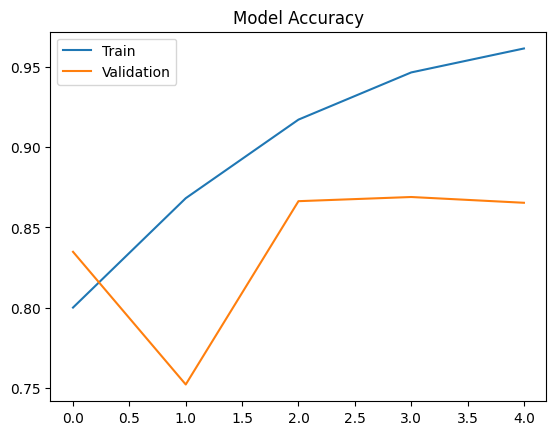

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 🔹 Load dataset
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# 🔹 Preprocessing (Padding)
max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# 🔹 Build Model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.summary()

# 🔹 Compile
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 🔹 Train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# 🔹 Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# 🔹 Plot Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()